# PEM voltage cutoff

Goal: estimate the voltage where the PEM fuel cell begins to collapse during discharge.

This cutoff is used so the EMS does not operate the PEM in the unstable low-voltage region.
We use the repeated charge-discharge tests and detect the first sustained voltage drop after the normal plateau.


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# This makes the notebook work both from the repo root and from its own folder.
PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "data").exists():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise FileNotFoundError("Could not find the project root folder containing data/")
    PROJECT_ROOT = PROJECT_ROOT.parent

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 120)


## 1. Load the PEM discharge tests


In [3]:
pem_folder = PROJECT_ROOT / "data/PEM_test/charge_discharge"
discharge_files = sorted(pem_folder.glob("discharge_*s_r1.csv")) + [pem_folder / "discharge_PEM_full.csv"]

print("Files used:")
for file in discharge_files:
    print(" -", file.name)


Files used:
 - discharge_020A_120s_r1.csv
 - discharge_020A_30s_r1.csv
 - discharge_020A_60s_r1.csv
 - discharge_030A_120s_r1.csv
 - discharge_030A_30s_r1.csv
 - discharge_030A_60s_r1.csv
 - discharge_040A_120s_r1.csv
 - discharge_040A_30s_r1.csv
 - discharge_040A_60s_r1.csv
 - discharge_PEM_full.csv


## 2. Correct voltage and current, then select the discharge part


In [4]:
COLLAPSE_ROLLING_WINDOW = 5
COLLAPSE_STARTUP_IGNORE_S = 20.0
COLLAPSE_DVDT_SIGMA = 6.0
COLLAPSE_MIN_DVDT_MAGNITUDE_V_PER_S = 0.002
STABLE_POINTS = 3

def load_pem_file(file):
    df = pd.read_csv(file)
    df["timestamp"] = pd.to_datetime(df["timestamp"])
    df["time_s"] = (df["timestamp"] - df["timestamp"].iloc[0]).dt.total_seconds()
    df["pem_voltage_V"] = df["ina4_bus_V"] - 0.064
    df["pem_current_A"] = 0.843 * (df["ina4_current_mA"] / 1000) + 0.001
    df["pem_output_current_A"] = (-df["pem_current_A"]).clip(lower=0)
    df["pem_power_W"] = df["pem_voltage_V"] * df["pem_current_A"]
    return df

def contiguous_segments(df, mask):
    mask = np.asarray(mask, dtype=bool)
    if len(mask) == 0 or not mask.any():
        return []

    edges = np.diff(np.concatenate(([0], mask.astype(int), [0])))
    starts = np.where(edges == 1)[0]
    ends = np.where(edges == -1)[0]
    return [df.iloc[start:end].copy() for start, end in zip(starts, ends)]

def trim_discharge(segment):
    if len(segment) < 2:
        return segment

    segment = segment.copy()
    segment["discharge_time_s"] = segment["time_s"] - segment["time_s"].iloc[0]

    # Only trim near-zero current at the end, not the first switch transient.
    abs_current = abs(segment["pem_current_A"]).to_numpy()
    search_start = max(int(len(abs_current) * 0.20), 30)
    if search_start >= len(abs_current):
        return segment

    near_zero = abs_current[search_start:] < 0.005
    zero_edges = np.diff(np.concatenate(([0], near_zero.astype(int), [0])))
    zero_starts = np.where(zero_edges == 1)[0]
    zero_ends = np.where(zero_edges == -1)[0]

    for start, end in zip(zero_starts, zero_ends):
        if end - start >= STABLE_POINTS:
            segment = segment.iloc[:search_start + start].copy()
            segment["discharge_time_s"] = segment["time_s"] - segment["time_s"].iloc[0]
            break

    return segment

def discharge_energy_score(segment):
    if len(segment) < 2:
        return 0.0
    return float(np.trapezoid(abs(segment["pem_power_W"]), segment["discharge_time_s"]))

def select_discharge(df):
    # The full file contains more than one scenario 6 segment. Pick the segment with most energy.
    discharge_mask = (df["scenario"] == 6) | (df["pem_current_A"] < -0.005)
    segments = contiguous_segments(df, discharge_mask)

    best = pd.DataFrame()
    best_score = -np.inf
    for segment in segments:
        segment = trim_discharge(segment)
        score = discharge_energy_score(segment)
        if score > best_score:
            best = segment
            best_score = score

    return best.reset_index(drop=True)

pem_discharge_tests = {}
for file in discharge_files:
    df = load_pem_file(file)
    pem_discharge_tests[file.name] = select_discharge(df)

display(pem_discharge_tests[discharge_files[0].name].head())


,timestamp,scenario,mode,K1,K2,K3,K4,K5,K6,K7,ina1_ok,ina1_bus_V,ina1_current_mA,ina1_power_mW,ina1_shunt_mV,ina2_ok,ina2_bus_V,ina2_current_mA,ina2_power_mW,ina2_shunt_mV,ina3_ok,ina3_bus_V,ina3_current_mA,ina3_power_mW,ina3_shunt_mV,ina4_ok,ina4_bus_V,ina4_current_mA,ina4_power_mW,ina4_shunt_mV,time_s,pem_voltage_V,pem_current_A,pem_output_current_A,pem_power_W,discharge_time_s
0,2026-04-30 09:13:22,6,Scenario 6: PEM -> Load,0,0,1,1,1,0,1,1,0.0,-0.025,0.0,-0.0025,1,0.0000,-0.025,0.0,-0.0025,1,1.4162,-0.475,1.25,-0.0475,1,1.3687,-0.35,0.625,-0.035,136.0,1.3047,0.000705,0.0,0.000920,0.0
1,2026-04-30 09:13:23,6,Scenario 6: PEM -> Load,0,0,1,1,1,0,1,1,0.0,-0.025,0.0,-0.0025,1,0.0000,-0.025,0.0,-0.0025,1,1.4162,-0.475,1.25,-0.0475,1,1.3687,-0.35,0.625,-0.035,137.0,1.3047,0.000705,0.0,0.000920,1.0
2,2026-04-30 09:13:24,6,Scenario 6: PEM -> Load,0,0,1,1,1,0,1,1,0.0,-0.025,0.0,-0.0025,1,1.3613,0.000,0.0,0.0000,1,0.4175,-0.125,0.00,-0.0125,1,1.3600,0.00,0.000,0.000,138.0,1.2960,0.001000,0.0,0.001296,2.0
3,2026-04-30 09:13:25,6,Scenario 6: PEM -> Load,0,0,1,1,1,0,1,1,0.0,-0.025,0.0,-0.0025,1,1.3600,-0.025,0.0,-0.0025,1,0.0962,-0.125,0.00,-0.0125,1,1.3587,0.00,0.000,0.000,139.0,1.2947,0.001000,0.0,0.001295,3.0
4,2026-04-30 09:13:26,6,Scenario 6: PEM -> Load,0,0,1,1,1,0,1,1,0.0,-0.025,0.0,-0.0025,1,1.3575,0.000,0.0,0.0000,1,0.0000,-0.125,0.00,-0.0125,1,1.3575,0.00,0.000,0.000,140.0,1.2935,0.001000,0.0,0.001293,4.0


## 3. Plot all discharge curves


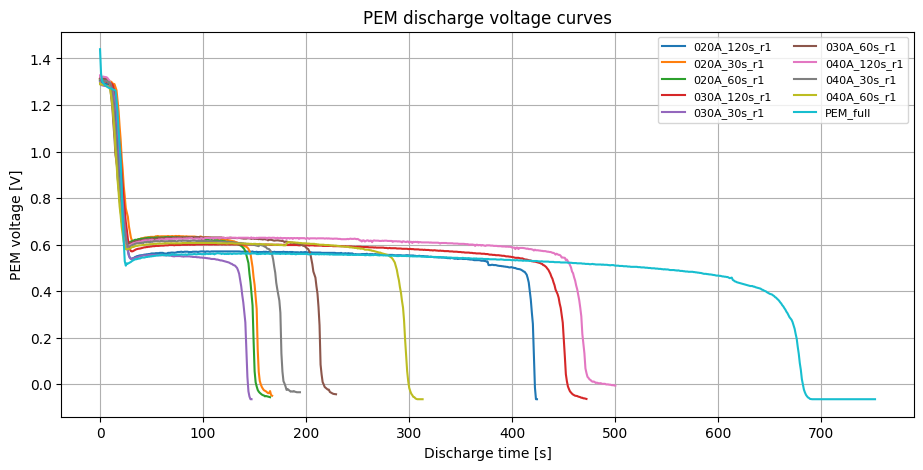

In [5]:
plt.figure(figsize=(11, 5))
for name, df in pem_discharge_tests.items():
    plt.plot(df["discharge_time_s"], df["pem_voltage_V"], label=name.replace("discharge_", "").replace(".csv", ""))
plt.title("PEM discharge voltage curves")
plt.xlabel("Discharge time [s]")
plt.ylabel("PEM voltage [V]")
plt.grid(True)
plt.legend(ncol=2, fontsize=8)
plt.show()


## 4. Detect the collapse voltage

Logic we use for detection

1. smooth the voltage with a 5 point median
2. calculate dV/dt
3. estimate the normal plateau slope
4. trigger collapse when dV/dt becomes clearly more negative than the plateau

The minimum extra drop rate is 0.002 V/s, and it must happen for 3 points in a row.


In [6]:
def detect_collapse(discharge):
    if len(discharge) < COLLAPSE_ROLLING_WINDOW + STABLE_POINTS:
        return None

    segment = (
        discharge.groupby("discharge_time_s", as_index=False)
        .agg(
            {
                "time_s": "first",
                "pem_voltage_V": "mean",
                "pem_current_A": "mean",
                "pem_power_W": "mean",
            }
        )
        .sort_values("discharge_time_s")
        .reset_index(drop=True)
    )

    time_s = segment["discharge_time_s"].to_numpy(dtype=float)
    voltage = segment["pem_voltage_V"].to_numpy(dtype=float)
    smooth_voltage = (
        pd.Series(voltage)
        .rolling(COLLAPSE_ROLLING_WINDOW, center=True, min_periods=1)
        .median()
        .to_numpy()
    )

    if len(np.unique(time_s)) < 2:
        return None

    dvdt = np.gradient(smooth_voltage, time_s)
    duration_s = time_s[-1] - time_s[0]
    ignore_until_s = max(COLLAPSE_STARTUP_IGNORE_S, 0.20 * duration_s)

    plateau_mask = (time_s >= ignore_until_s) & (time_s <= ignore_until_s + 0.30 * duration_s)
    plateau_dvdt = dvdt[plateau_mask]
    plateau_dvdt = plateau_dvdt[np.isfinite(plateau_dvdt)]
    if len(plateau_dvdt) < STABLE_POINTS:
        return None

    baseline = float(np.median(plateau_dvdt))
    mad = float(np.median(np.abs(plateau_dvdt - baseline)))
    robust_sigma = 1.4826 * mad
    threshold = baseline - max(
        COLLAPSE_DVDT_SIGMA * robust_sigma,
        COLLAPSE_MIN_DVDT_MAGNITUDE_V_PER_S,
    )

    collapse_condition = (time_s >= ignore_until_s) & (dvdt <= threshold)
    consecutive = np.convolve(
        collapse_condition.astype(int),
        np.ones(STABLE_POINTS, dtype=int),
        mode="valid",
    )
    candidate_indices = np.where(consecutive == STABLE_POINTS)[0]
    if len(candidate_indices) == 0:
        return None

    collapse_index = int(candidate_indices[0])
    return {
        "collapse_time_s": time_s[collapse_index],
        "collapse_voltage_V": smooth_voltage[collapse_index],
        "collapse_dVdt_V_per_s": dvdt[collapse_index],
        "collapse_dVdt_threshold_V_per_s": threshold,
    }

collapse_rows = []
for name, discharge in pem_discharge_tests.items():
    collapse = detect_collapse(discharge)
    if collapse is not None:
        collapse_rows.append(
            {
                "file": name,
                **collapse,
            }
        )

collapse_summary = pd.DataFrame(collapse_rows)
display(collapse_summary)


,file,collapse_time_s,collapse_voltage_V,collapse_dVdt_V_per_s,collapse_dVdt_threshold_V_per_s
0,discharge_020A_120s_r1.csv,409.0,0.4910,-0.002500,-0.002
1,discharge_020A_30s_r1.csv,138.0,0.6010,-0.002500,-0.002
2,discharge_020A_60s_r1.csv,136.0,0.5972,-0.002500,-0.002
3,discharge_030A_120s_r1.csv,429.0,0.5173,-0.003100,-0.002
4,discharge_030A_30s_r1.csv,128.0,0.5173,-0.002500,-0.002
5,discharge_030A_60s_r1.csv,199.0,0.5922,-0.003700,-0.002
6,discharge_040A_120s_r1.csv,451.0,0.5435,-0.005200,-0.002
7,discharge_040A_30s_r1.csv,164.0,0.5810,-0.003150,-0.002
8,discharge_040A_60s_r1.csv,279.0,0.5560,-0.002083,-0.002
9,discharge_PEM_full.csv,613.0,0.4560,-0.005417,-0.002


## 5. Use the median collapse voltage as the cutoff


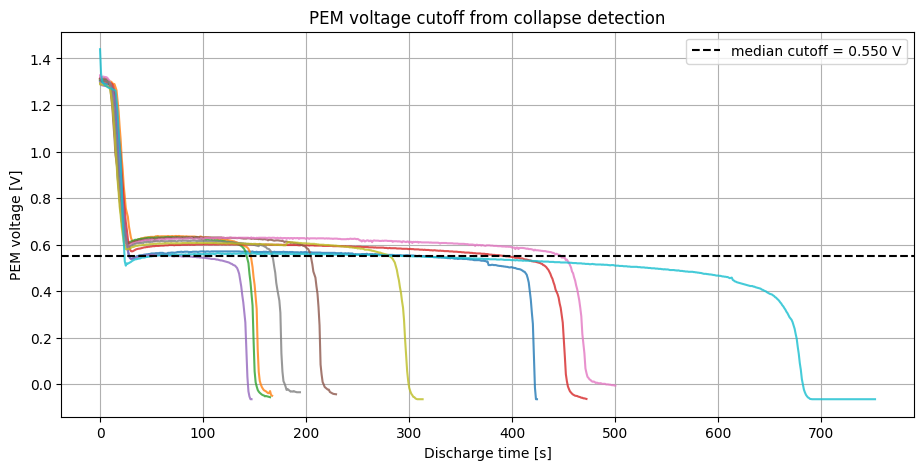

PEM_MIN_USABLE_VOLTAGE = 0.5498 V


In [7]:
PEM_MIN_USABLE_VOLTAGE = collapse_summary["collapse_voltage_V"].median()

plt.figure(figsize=(11, 5))
for name, df in pem_discharge_tests.items():
    plt.plot(df["discharge_time_s"], df["pem_voltage_V"], alpha=0.8)
plt.axhline(PEM_MIN_USABLE_VOLTAGE, color="black", linestyle="--", label=f"median cutoff = {PEM_MIN_USABLE_VOLTAGE:.3f} V")
plt.title("PEM voltage cutoff from collapse detection")
plt.xlabel("Discharge time [s]")
plt.ylabel("PEM voltage [V]")
plt.legend()
plt.grid(True)
plt.show()

print(f"PEM_MIN_USABLE_VOLTAGE = {PEM_MIN_USABLE_VOLTAGE:.4f} V")


## 6. Critical note

The full-discharge test falls to a lower voltage than the repeated short tests. That is useful for
hydrogen consumption at the very end of a full test, but it should not define the normal EMS cutoff.
The median cutoff is more robust because it uses the repeated collapse onset points.
